# causal-learn Tutorial 07: CD-NOD For Nonstationary Data

Most causal discovery examples quietly assume that every row comes from the same stable data-generating process. In real datasets, that assumption can fail. Users may come from different markets, products may change over time, ranking systems may be updated, or measurement policies may shift across collection periods. If we pool all of that data and pretend it is stationary, ordinary discovery algorithms can confuse distribution shift with causal structure.

This notebook introduces **CD-NOD**, causal discovery from nonstationary or heterogeneous data. CD-NOD extends constraint-based discovery by adding a **domain or time index** that captures changing environments. That environment index is not a causal treatment in the usual effect-estimation sense. It is a marker for distributional change that can help identify which variables or mechanisms vary across environments.

The practical questions are:

- What changes across environments?
- How does pooled PC behave when the data are heterogeneous?
- What does CD-NOD add by using an environment index?
- How should we report environment-driven edges without overclaiming them as ordinary causal mechanisms?

## Notebook Flow

We will study nonstationary discovery in a step-by-step way:

1. Set up imports, output paths, PC, CD-NOD, and plotting helpers.
2. Load the synthetic nonstationary dataset created earlier in the tutorial series.
3. Document the variable roles and the true environment-driven shifts.
4. Audit environment balance, mean shifts, and relationship shifts.
5. Run pooled PC while ignoring the environment index.
6. Run separate PC models within each environment to show instability across domains.
7. Run CD-NOD with the environment index and inspect the augmented graph.
8. Add simple temporal/background knowledge to make CD-NOD's orientations easier to interpret.
9. Run alpha sensitivity and save a reporting checklist.

Every code cell is introduced with context and followed by a short discussion so the notebook remains teachable rather than just executable.

## CD-NOD Theory

CD-NOD is designed for causal discovery when the data are nonstationary or heterogeneous across environments. Instead of treating distribution shift as a nuisance only, CD-NOD uses shift as a source of causal information.

The intuition is that causal mechanisms can change across environments in structured ways. If an environment or context variable changes the distribution of a cause, the effect may shift downstream. If the mechanism generating a variable changes directly, that variable may show environment dependence even after conditioning on its ordinary parents.

CD-NOD adds an environment or domain index to the discovery problem so the algorithm can reason about these changing mechanisms.

## Distribution Shift As A Causal Signal

In ordinary pooled analysis, distribution shift is often treated as a problem: it violates the assumption that all rows are identically distributed. CD-NOD treats the shift as informative.

Imagine data from three environments. If `intent` shifts across environments and `match` depends on `intent`, then `match` may shift too. That downstream shift does not necessarily mean the environment directly causes `match`; it may be inherited through `intent`.

The discovery question becomes: which variables are directly affected by the environment, and which variables shift only because their causes shifted?

## The Environment Variable

CD-NOD typically introduces a context variable, often called `C`, `domain`, or `environment`. This variable indexes the regime from which each row came.

Edges involving the environment variable have a special meaning. An edge from the environment into a substantive variable suggests that the variable's distribution or mechanism changes directly across environments.

The environment variable is not usually a manipulable treatment in the ordinary sense. It is a marker of regime changes. That distinction matters when explaining environment-target edges.

## Invariant And Non-Invariant Mechanisms

A causal mechanism is invariant if the conditional distribution of a variable given its parents stays stable across environments. For example, if `engagement` is generated from `match` in the same way in every environment, its mechanism is invariant even if the marginal distribution of `engagement` changes because `match` changes.

A mechanism is non-invariant if the relationship itself changes. For example, if `match -> engagement` is stronger in one environment than another, then the conditional mechanism for `engagement` has shifted.

CD-NOD uses conditional independence relationships involving the environment variable to help distinguish inherited distribution changes from direct mechanism changes.

## Why Pooled PC Can Mislead Under Shift

If we ignore environments and pool all rows, the data may look like it came from one stable distribution even though it is a mixture of regimes. That mixture can create dependencies that are not present within any single environment or hide dependencies that are environment-specific.

Pooled PC can therefore add edges that explain regime mixture rather than causal structure. It can also miss edges when effects differ across environments and partially cancel in the pooled sample.

This is why CD-NOD workflows often compare pooled PC, per-environment PC, and environment-aware CD-NOD results.

## What CD-NOD Can And Cannot Claim

CD-NOD can use nonstationarity to suggest causal directions and mechanism-change targets. It is especially useful when data come from known regimes, time periods, markets, experiments, or deployment phases.

It cannot automatically explain why an environment changed a mechanism. The environment variable is usually a label, not a detailed causal variable. CD-NOD also depends on conditional independence tests, sufficient variation across environments, and a meaningful environment definition.

A good CD-NOD report separates ordinary causal edges from environment-target edges and explains whether each environment-target edge is interpreted as a direct mechanism change, a distribution shift, or a cautious exploratory signal.

## Setup

This cell imports the scientific stack, causal-learn's PC and CD-NOD implementations, background-knowledge utilities, and plotting tools. CD-NOD can print progress text from its internal skeleton search even when progress bars are disabled, so the helper functions later capture standard output and standard error during algorithm calls.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import contextlib
import io
import os
import warnings

# Keep matplotlib cache writes inside the repository so execution works in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from causallearn.graph.GraphNode import GraphNode
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.CDNOD import cdnod
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge

# Resolve paths whether the notebook is run from the repository root or from this notebook folder.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PREFIX = "07"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"

packages = ["causal-learn", "numpy", "pandas", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)

,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table is the reproducibility anchor. CD-NOD depends on many conditional independence decisions, so the exact library versions are part of the analysis record.

## Load The Nonstationary Teaching Dataset

Notebook 02 created a dataset named `02_nonstationary_continuous.csv`. It contains the same six substantive variables used in earlier tutorials plus an `environment` column. The environment column is the domain index passed to CD-NOD.

In this synthetic setup, the environment changes the root distributions of `need` and `intent`, and it also changes part of the mechanism feeding into `match`. That gives CD-NOD something meaningful to detect.

In [2]:
# Load nonstationary data and the synthetic truth table.
nonstationary_path = DATASET_DIR / "02_nonstationary_continuous.csv"
truth_path = TABLE_DIR / "02_nonstationary_continuous_true_edges.csv"
environment_summary_path = TABLE_DIR / "02_nonstationary_environment_summary.csv"

required_paths = [nonstationary_path, truth_path, environment_summary_path]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Run tutorial notebook 02 first. Missing files: " + ", ".join(missing_paths))

data_df = pd.read_csv(nonstationary_path)
true_edges = pd.read_csv(truth_path)
original_environment_summary = pd.read_csv(environment_summary_path)

ENV_COLUMN = "environment"
VARIABLES = [column for column in data_df.columns if column != ENV_COLUMN]
AUGMENTED_VARIABLES = VARIABLES + [ENV_COLUMN]

loaded_summary = pd.DataFrame(
    [
        {
            "dataset": "nonstationary_continuous",
            "rows": len(data_df),
            "columns": data_df.shape[1],
            "environment_values": sorted(data_df[ENV_COLUMN].unique().tolist()),
            "source_file": nonstationary_path.name,
        }
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)

display(loaded_summary)
display(data_df.head())
display(true_edges)

,dataset,rows,columns,environment_values,source_file
0,nonstationary_continuous,2500,7,"[0, 1, 2]",02_nonstationary_continuous.csv


,environment,need,intent,match,engagement,renewal,support
0,2,0.500619,0.652311,0.607523,1.021798,1.464456,-0.695260
1,2,-0.068357,-0.635389,-0.603599,0.376130,-0.156033,-0.285916
2,1,-0.257764,-3.403817,-2.065930,-2.199955,-2.253464,-1.407673
3,0,-0.050100,0.439419,0.707436,0.980496,1.322518,0.062189
4,2,0.562090,-1.236711,0.163411,0.369901,-0.825164,-0.460469


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support co...
6,environment,need,directed,The root need distribution shifts by environment.
7,environment,intent,directed,The root intent distribution shifts by environ...
8,environment,match,directed,The intent-to-match mechanism changes by envir...


The dataset has three environments and six continuous observed variables. The truth table includes ordinary causal edges among the observed variables plus environment-driven shift edges from `environment` to `need`, `intent`, and `match`.

## Field Guide For Variables And Environment Shifts

Before running algorithms, we spell out what each variable means and how the environment index should be interpreted. This prevents a common mistake: treating the environment node as if it were a manipulable treatment rather than a domain/time marker.

In [3]:
# Document variable roles and the meaning of the environment node.
field_guide = pd.DataFrame(
    [
        {"variable": "environment", "role": "domain index", "meaning": "which heterogeneous environment or collection domain generated the row", "cdnod_role": "context variable"},
        {"variable": "need", "role": "early context", "meaning": "baseline demand or user need signal", "cdnod_role": "observed variable"},
        {"variable": "intent", "role": "early context", "meaning": "current intent or short-term goal signal", "cdnod_role": "observed variable"},
        {"variable": "match", "role": "intermediate", "meaning": "quality of the match between item and user state", "cdnod_role": "observed variable"},
        {"variable": "engagement", "role": "intermediate", "meaning": "depth of short-term interaction", "cdnod_role": "observed variable"},
        {"variable": "renewal", "role": "downstream outcome", "meaning": "future value or retention-like outcome", "cdnod_role": "observed variable"},
        {"variable": "support", "role": "downstream outcome", "meaning": "future support or friction-like outcome", "cdnod_role": "observed variable"},
    ]
)

shift_edges = true_edges[true_edges["source"] == ENV_COLUMN].copy()
ordinary_edges = true_edges[true_edges["source"] != ENV_COLUMN].copy()

field_guide.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_field_guide.csv", index=False)
shift_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_environment_shift_edges.csv", index=False)
ordinary_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_ordinary_edges.csv", index=False)

display(field_guide)
display(shift_edges)
display(ordinary_edges)

,variable,role,meaning,cdnod_role
0,environment,domain index,which heterogeneous environment or collection ...,context variable
1,need,early context,baseline demand or user need signal,observed variable
2,intent,early context,current intent or short-term goal signal,observed variable
3,match,intermediate,quality of the match between item and user state,observed variable
4,engagement,intermediate,depth of short-term interaction,observed variable
5,renewal,downstream outcome,future value or retention-like outcome,observed variable
6,support,downstream outcome,future support or friction-like outcome,observed variable


,source,target,edge_type,mechanism
6,environment,need,directed,The root need distribution shifts by environment.
7,environment,intent,directed,The root intent distribution shifts by environ...
8,environment,match,directed,The intent-to-match mechanism changes by envir...


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support co...


The key distinction is now explicit. Ordinary edges describe causal relationships among substantive variables. Environment edges describe where distributions or mechanisms change across domains.

## Helper Functions

The next cell defines the reusable machinery for the notebook. The most important details are:

- CD-NOD names variables internally as `X1`, `X2`, ..., with the environment index appended last;
- we map those names back to human-readable labels;
- graph metrics separate ordinary-variable recovery from environment-shift recovery;
- CD-NOD execution is wrapped to suppress progress text and keep notebook outputs clean.

In [4]:
# CD-NOD augments the data matrix by appending c_indx as the last variable.
CDNOD_NAME_MAP = {f"X{i + 1}": name for i, name in enumerate(AUGMENTED_VARIABLES)}
REVERSE_CDNOD_NAME_MAP = {name: code for code, name in CDNOD_NAME_MAP.items()}


def parse_causallearn_edge(edge):
    """Convert a causal-learn edge object into source, endpoint pattern, and target strings."""
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}


def graph_to_edge_table(graph, label, name_map=None):
    """Return a tidy edge table from a causal-learn graph object."""
    rows = []
    for edge in graph.get_graph_edges():
        parsed = parse_causallearn_edge(edge)
        source = name_map.get(parsed["source"], parsed["source"]) if name_map else parsed["source"]
        target = name_map.get(parsed["target"], parsed["target"]) if name_map else parsed["target"]
        rows.append({"run": label, "source": source, "edge_type": parsed["edge_type"], "target": target})
    return pd.DataFrame(rows, columns=["run", "source", "edge_type", "target"])


def run_cdnod_quiet(data, c_index, label, alpha=0.05, background_knowledge=None):
    """Run CD-NOD while capturing progress text emitted by internal search code."""
    stdout_buffer = io.StringIO()
    stderr_buffer = io.StringIO()
    with contextlib.redirect_stdout(stdout_buffer), contextlib.redirect_stderr(stderr_buffer):
        result = cdnod(
            data,
            c_indx=c_index,
            alpha=alpha,
            indep_test="fisherz",
            stable=True,
            show_progress=False,
            background_knowledge=background_knowledge,
        )
    messages = [line for line in stdout_buffer.getvalue().splitlines() + stderr_buffer.getvalue().splitlines() if line.strip()]
    return result, pd.DataFrame({"run": label, "message": messages})


def directed_pairs(edge_df):
    """Extract definite directed pairs from an edge table."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs


def skeleton_pairs(edge_df):
    """Extract adjacencies while ignoring endpoint marks."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs


def summarize_against_truth(edge_df, truth_df, label):
    """Compute compact recovery metrics against a truth table."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)

    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton
    unresolved_true = 0
    for src, dst in true_directed:
        pair = frozenset([src, dst])
        if pair in learned_skeleton and (src, dst) not in learned_directed and (dst, src) not in learned_directed:
            unresolved_true += 1

    directed_count = len(learned_directed)
    return pd.DataFrame(
        [
            {
                "run": label,
                "learned_edges_total": len(edge_df),
                "definite_directed_edges": directed_count,
                "true_edges": len(true_directed),
                "correct_directed_edges": len(correct_directed),
                "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
                "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
                "reversed_true_edges": len(reversed_true),
                "unresolved_true_adjacencies": unresolved_true,
                "missing_true_adjacencies": len(missing_skeleton),
                "extra_adjacencies": len(extra_skeleton),
            }
        ]
    )


def classify_edges(edge_df, truth_df):
    """Label learned edges relative to the synthetic truth table."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    rows = []
    for row in edge_df.itertuples(index=False):
        pair = frozenset([row.source, row.target])
        learned_direction = None
        if row.edge_type == "-->":
            learned_direction = (row.source, row.target)
        elif row.edge_type == "<--":
            learned_direction = (row.target, row.source)

        if learned_direction in true_directed:
            status = "correct directed edge"
        elif learned_direction and (learned_direction[1], learned_direction[0]) in true_directed:
            status = "reversed true edge"
        elif pair in true_skeleton:
            status = "true adjacency with uncertain or wrong endpoint"
        else:
            status = "extra adjacency"
        rows.append({"source": row.source, "edge_type": row.edge_type, "target": row.target, "status": status})
    return pd.DataFrame(rows)


def make_cdnod_background_knowledge():
    """Create simple tier knowledge using CD-NOD's internal X-name convention."""
    tiers = {
        "environment": 0,
        "need": 1,
        "intent": 1,
        "match": 2,
        "engagement": 3,
        "renewal": 4,
        "support": 4,
    }
    knowledge = BackgroundKnowledge()
    nodes = {name: GraphNode(REVERSE_CDNOD_NAME_MAP[name]) for name in tiers}
    for name, tier in tiers.items():
        knowledge.add_node_to_tier(nodes[name], tier)
    knowledge.forbid_within_tier(4)
    return knowledge, tiers


GRAPH_POSITIONS = {
    "environment": (0.09, 0.50),
    "need": (0.28, 0.74),
    "intent": (0.28, 0.26),
    "match": (0.49, 0.50),
    "engagement": (0.72, 0.50),
    "renewal": (0.93, 0.74),
    "support": (0.93, 0.26),
}
NODE_LABELS = {
    "environment": "Environment",
    "need": "Need",
    "intent": "Intent",
    "match": "Match",
    "engagement": "Engagement",
    "renewal": "Renewal",
    "support": "Support",
}
NODE_COLORS = {
    "environment": "#f3f4f6",
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}


def trim_edge_to_box(start, end, box_w=0.14, box_h=0.095, gap=0.012):
    """Return edge endpoints that stop just outside source and target boxes."""
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end

    # FancyBboxPatch padding makes the visible box a little larger than box_w/box_h.
    effective_w = box_w + 0.04
    effective_h = box_h + 0.04
    x_limit = (effective_w / 2) / abs(dx) if dx else np.inf
    y_limit = (effective_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)


def draw_box_graph(edge_df, title, path, note=None, include_environment=True):
    """Draw a DAG/CPDAG-style graph with rounded boxes and visible arrowheads."""
    positions = GRAPH_POSITIONS if include_environment else {k: v for k, v in GRAPH_POSITIONS.items() if k != "environment"}
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    ax.set_xlim(-0.03, 1.05)
    ax.set_ylim(0.04, 0.96)
    box_w, box_h = 0.14, 0.095

    for row in edge_df.itertuples(index=False):
        if row.source not in positions or row.target not in positions:
            continue
        raw_start = positions[row.source]
        raw_end = positions[row.target]
        if row.edge_type == "<--":
            raw_start, raw_end = raw_end, raw_start
        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        if row.edge_type in {"-->", "<--"}:
            arrowstyle = "-|>"
            mutation_scale = 18
            linewidth = 1.8
            color = "#334155"
        else:
            arrowstyle = "-"
            mutation_scale = 1
            linewidth = 1.5
            color = "#64748b"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=mutation_scale,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)

    for node, (x, y) in positions.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def truth_as_edge_table(truth_df, label="truth"):
    """Convert a truth table into the plotting schema."""
    return truth_df.assign(run=label, edge_type="-->")[["run", "source", "edge_type", "target"]]

These helpers keep the later analysis cells focused. The name mapping is especially important: causal-learn's CD-NOD output uses `X1` through `X7`, but the notebook reports `need`, `intent`, `match`, `engagement`, `renewal`, `support`, and `environment`.

## CD-NOD Concept Map

CD-NOD is easiest to understand by contrasting it with pooled PC. Pooled PC asks for one stable graph over the observed variables. CD-NOD augments the system with a context index and asks which variables or mechanisms appear to change with that context.

In [5]:
# Summarize the conceptual difference between pooled PC and CD-NOD.
concept_map = pd.DataFrame(
    [
        {
            "method": "pooled PC",
            "uses_environment_index": False,
            "main_question": "What graph is implied if every row is treated as coming from one stationary process?",
            "main_risk": "Distribution shifts can create extra adjacencies or unstable orientations.",
        },
        {
            "method": "per-environment PC",
            "uses_environment_index": False,
            "main_question": "Does the graph look similar when each environment is analyzed separately?",
            "main_risk": "Smaller within-environment samples can make results noisy.",
        },
        {
            "method": "CD-NOD",
            "uses_environment_index": True,
            "main_question": "Which variables are connected to the context index, and what graph is learned on the augmented system?",
            "main_risk": "Environment edges indicate nonstationarity, not automatically manipulable causal effects.",
        },
    ]
)
concept_map.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_method_concept_map.csv", index=False)
display(concept_map)

,method,uses_environment_index,main_question,main_risk
0,pooled PC,False,What graph is implied if every row is treated ...,Distribution shifts can create extra adjacenci...
1,per-environment PC,False,Does the graph look similar when each environm...,Smaller within-environment samples can make re...
2,CD-NOD,True,Which variables are connected to the context i...,"Environment edges indicate nonstationarity, no..."


This table sets the reporting standard for the notebook. We will use pooled PC and per-environment PC as diagnostics, then use CD-NOD to model the environment index directly.

## Draw The Reference Nonstationary Graph

The reference graph includes both ordinary causal edges and environment shift edges. The environment node should be read as a context marker: it points to variables whose distributions or mechanisms change across domains.

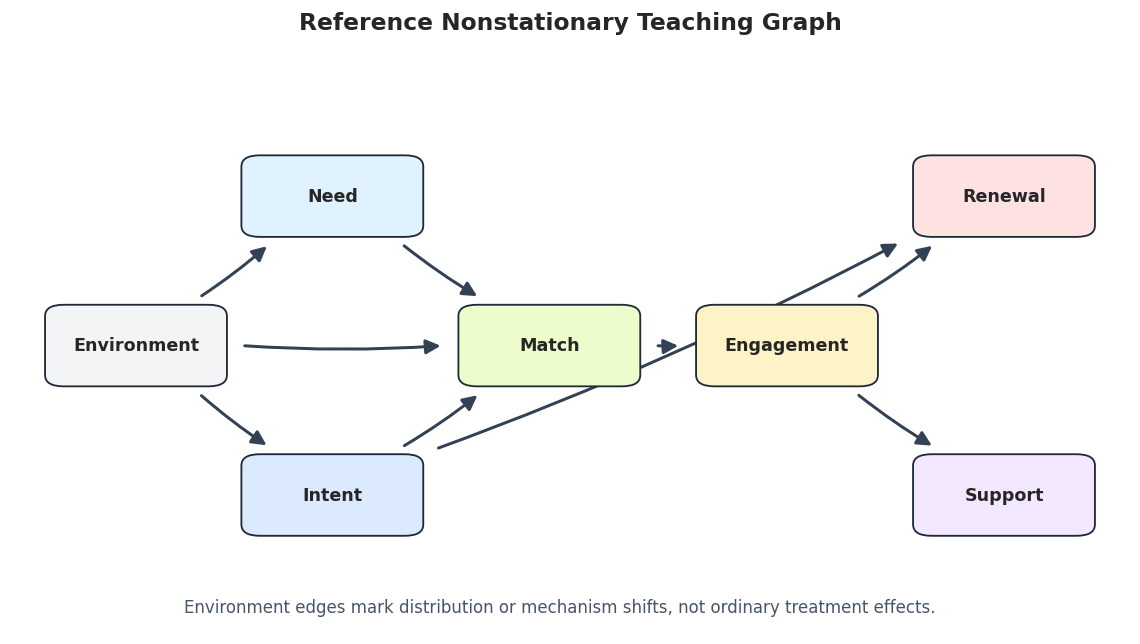

In [6]:
# Draw the synthetic reference graph for the nonstationary dataset.
true_edge_table = truth_as_edge_table(true_edges, label="true_nonstationary_graph")
true_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_nonstationary_graph.png"
draw_box_graph(
    true_edge_table,
    title="Reference Nonstationary Teaching Graph",
    path=true_graph_path,
    note="Environment edges mark distribution or mechanism shifts, not ordinary treatment effects.",
    include_environment=True,
)

The reference graph highlights the teaching challenge. If the environment affects roots and mechanisms, pooled discovery may blend distinct regimes into one unstable graph.

## Environment Balance And Mean Shifts

Before running discovery, we audit how many rows belong to each environment and how variable means differ across environments. CD-NOD needs a meaningful context index; if the environments do not differ, there may be little nonstationary signal to discover.

In [7]:
# Summarize row balance and mean shifts by environment.
environment_summary = (
    data_df.groupby(ENV_COLUMN)
    .agg(
        rows=(ENV_COLUMN, "size"),
        need_mean=("need", "mean"),
        intent_mean=("intent", "mean"),
        match_mean=("match", "mean"),
        engagement_mean=("engagement", "mean"),
        renewal_mean=("renewal", "mean"),
        support_mean=("support", "mean"),
    )
    .reset_index()
)

mean_shift_long = environment_summary.melt(
    id_vars=[ENV_COLUMN, "rows"],
    value_vars=[f"{variable}_mean" for variable in VARIABLES],
    var_name="variable",
    value_name="mean",
)
mean_shift_long["variable"] = mean_shift_long["variable"].str.replace("_mean", "", regex=False)

environment_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_environment_summary.csv", index=False)
mean_shift_long.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_environment_mean_shifts_long.csv", index=False)

display(environment_summary)
display(original_environment_summary)

,environment,rows,need_mean,intent_mean,match_mean,engagement_mean,renewal_mean,support_mean
0,0,834,-0.419768,0.334375,-0.048747,-0.044390,0.109419,-0.025874
1,1,833,-0.047202,0.027199,0.044692,0.050366,0.060080,0.037340
2,2,833,0.467474,-0.361976,0.004113,-0.005923,-0.169630,-0.011435


,environment,rows,need_mean,intent_mean,match_mean,renewal_mean,support_mean
0,0,834,-0.419768,0.334375,-0.048747,0.109419,-0.025874
1,1,833,-0.047202,0.027199,0.044692,0.060080,0.037340
2,2,833,0.467474,-0.361976,0.004113,-0.169630,-0.011435


The row counts are balanced by construction, so differences across environments are not caused by one tiny group. The means show deliberate shifts in early variables such as `need` and `intent`, which should make the environment index informative.

## Plot Mean Shifts Across Environments

The table is precise, but a plot makes the shift pattern easier to see. We expect `need` and `intent` to visibly move across environments because those are true environment-shift targets.

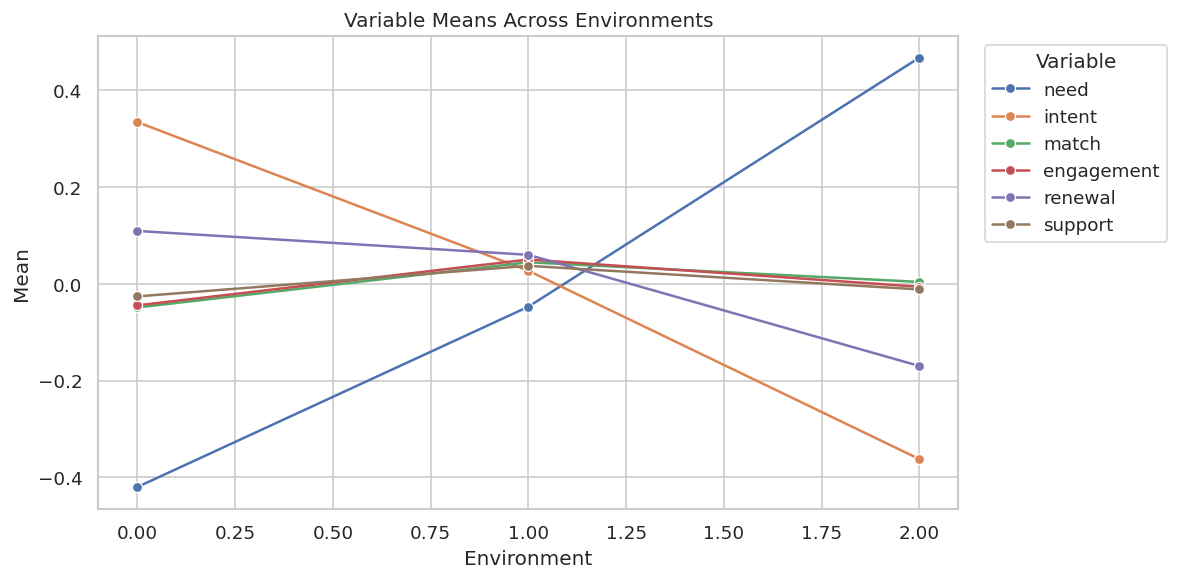

In [8]:
# Plot mean shifts by environment for every observed variable.
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=mean_shift_long, x=ENV_COLUMN, y="mean", hue="variable", marker="o", ax=ax)
ax.set_title("Variable Means Across Environments")
ax.set_xlabel("Environment")
ax.set_ylabel("Mean")
ax.legend(title="Variable", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_environment_mean_shifts.png", dpi=160, bbox_inches="tight")
plt.show()

The plot confirms that the environments are not interchangeable. Some variables shift clearly, and that is the signal CD-NOD tries to incorporate rather than treating as nuisance variation.

## Mechanism Shift Diagnostic: Intent To Match By Environment

The truth table says the environment changes the mechanism feeding into `match`. A simple diagnostic is to estimate the slope of `match` on `intent` separately inside each environment. This is not a causal proof, but it helps explain why the same pooled relationship can be misleading.

In [9]:
# Estimate simple within-environment slopes as a descriptive mechanism-shift diagnostic.
slope_rows = []
for environment, group in data_df.groupby(ENV_COLUMN):
    slope, intercept = np.polyfit(group["intent"], group["match"], deg=1)
    corr = group[["intent", "match"]].corr().iloc[0, 1]
    slope_rows.append(
        {
            "environment": environment,
            "intent_to_match_slope": slope,
            "intent_to_match_intercept": intercept,
            "intent_match_correlation": corr,
            "rows": len(group),
        }
    )

mechanism_shift = pd.DataFrame(slope_rows)
mechanism_shift.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_intent_match_mechanism_shift.csv", index=False)
display(mechanism_shift)

,environment,intent_to_match_slope,intent_to_match_intercept,intent_match_correlation,rows
0,0,0.506333,-0.218053,0.526991,834
1,1,0.672869,0.026391,0.673745,833
2,2,0.837357,0.307217,0.720183,833


The slopes are not identical across environments, which is exactly the kind of heterogeneity that motivates a nonstationary discovery method. The next plot makes that relationship shift visible.

## Plot The Intent-To-Match Shift

A scatterplot with separate regression lines by environment shows whether the relationship between `intent` and `match` changes across domains. This plot is descriptive, but it gives intuition for the algorithmic results that follow.

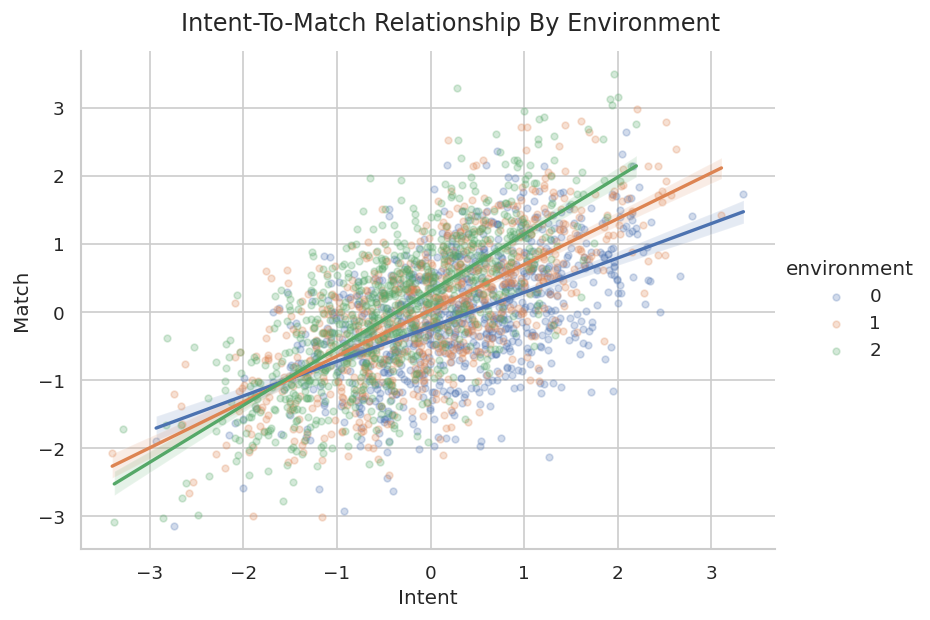

In [10]:
# Visualize the relationship between intent and match separately by environment.
g = sns.lmplot(
    data=data_df,
    x="intent",
    y="match",
    hue=ENV_COLUMN,
    height=5,
    aspect=1.35,
    scatter_kws={"alpha": 0.25, "s": 16},
    line_kws={"linewidth": 2},
)
g.fig.suptitle("Intent-To-Match Relationship By Environment", y=1.03)
g.set_axis_labels("Intent", "Match")
g.fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_intent_match_shift.png", dpi=160, bbox_inches="tight")
plt.show()

The relationship lines differ enough to justify treating environment as more than a row label. We now run pooled PC to see what happens when the environment index is ignored.

## Pooled PC Ignoring Environment

Pooled PC treats all rows as if they came from one stationary process. This is a useful baseline because it shows what a standard constraint-based workflow would do before we introduce CD-NOD.

In [11]:
# Run ordinary PC on the pooled observed variables, ignoring environment.
pooled_pc = pc(
    data_df[VARIABLES].to_numpy(),
    alpha=0.05,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=VARIABLES,
)
pooled_pc_edges = graph_to_edge_table(pooled_pc.G, label="pooled_pc_ignoring_environment")
pooled_pc_metrics = summarize_against_truth(pooled_pc_edges, ordinary_edges, "pooled_pc_ignoring_environment")
pooled_pc_classified = classify_edges(pooled_pc_edges, ordinary_edges)

pooled_pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pooled_pc_edges.csv", index=False)
pooled_pc_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pooled_pc_metrics.csv", index=False)
pooled_pc_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pooled_pc_edge_classification.csv", index=False)

display(pooled_pc_edges)
display(pooled_pc_metrics)
display(pooled_pc_classified)

,run,source,edge_type,target
0,pooled_pc_ignoring_environment,need,---,intent
1,pooled_pc_ignoring_environment,need,---,match
2,pooled_pc_ignoring_environment,intent,---,match
3,pooled_pc_ignoring_environment,intent,-->,renewal
4,pooled_pc_ignoring_environment,match,---,engagement
5,pooled_pc_ignoring_environment,engagement,-->,renewal
6,pooled_pc_ignoring_environment,engagement,---,support


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,pooled_pc_ignoring_environment,7,2,6,2,1.0,0.333333,0,4,0,1


,source,edge_type,target,status
0,need,---,intent,extra adjacency
1,need,---,match,true adjacency with uncertain or wrong endpoint
2,intent,---,match,true adjacency with uncertain or wrong endpoint
3,intent,-->,renewal,correct directed edge
4,match,---,engagement,true adjacency with uncertain or wrong endpoint
5,engagement,-->,renewal,correct directed edge
6,engagement,---,support,true adjacency with uncertain or wrong endpoint


The pooled PC graph contains extra or unresolved structure relative to the ordinary truth table. That is the expected failure mode: pooling heterogeneous environments can make the algorithm explain distribution shifts using observed-variable edges.

## Draw The Pooled PC Graph

The pooled PC graph is drawn without the environment node because the algorithm did not use it. Comparing this figure with later CD-NOD graphs makes the role of the environment index concrete.

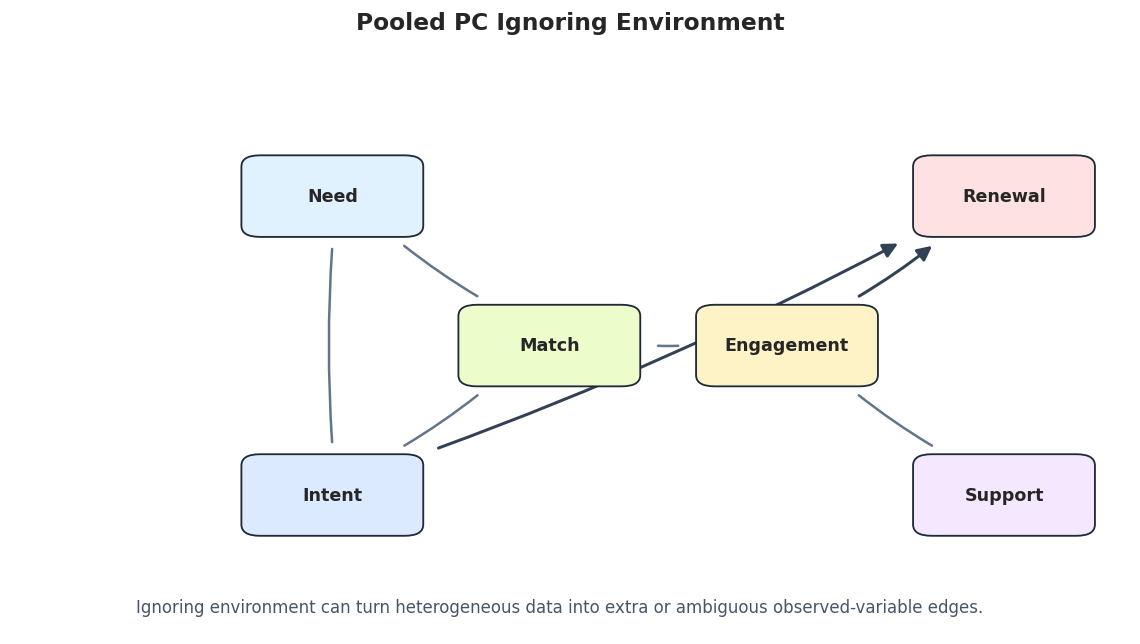

In [12]:
# Draw the pooled PC graph.
pooled_pc_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pooled_pc_graph.png"
draw_box_graph(
    pooled_pc_edges,
    title="Pooled PC Ignoring Environment",
    path=pooled_pc_graph_path,
    note="Ignoring environment can turn heterogeneous data into extra or ambiguous observed-variable edges.",
    include_environment=False,
)

The graph is readable but incomplete as an analysis of nonstationarity. It has no way to indicate that some variables shift across environments. The next diagnostic runs PC separately inside each environment.

## Per-Environment PC Diagnostics

Running PC separately by environment is not a replacement for CD-NOD, but it is a useful diagnostic. If the learned graph changes by environment, that is evidence that a single pooled stationary graph may be too simple.

In [13]:
# Run PC separately inside each environment.
per_environment_edges = []
per_environment_metrics = []
for environment, group in data_df.groupby(ENV_COLUMN):
    label = f"pc_environment_{environment}"
    result = pc(
        group[VARIABLES].to_numpy(),
        alpha=0.05,
        indep_test="fisherz",
        stable=True,
        show_progress=False,
        node_names=VARIABLES,
    )
    edge_table = graph_to_edge_table(result.G, label=label)
    per_environment_edges.append(edge_table.assign(environment=environment))
    per_environment_metrics.append(summarize_against_truth(edge_table, ordinary_edges, label).assign(environment=environment))

per_environment_edges_df = pd.concat(per_environment_edges, ignore_index=True)
per_environment_metrics_df = pd.concat(per_environment_metrics, ignore_index=True)

per_environment_edges_df.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_per_environment_pc_edges.csv", index=False)
per_environment_metrics_df.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_per_environment_pc_metrics.csv", index=False)

display(per_environment_metrics_df)
display(per_environment_edges_df)

,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,environment
0,pc_environment_0,6,5,6,5,1.000000,0.833333,0,1,0,0,0
1,pc_environment_1,7,7,6,6,0.857143,1.000000,0,0,0,1,1
2,pc_environment_2,6,6,6,6,1.000000,1.000000,0,0,0,0,2


,run,source,edge_type,target,environment
0,pc_environment_0,need,-->,match,0
1,pc_environment_0,intent,-->,match,0
2,pc_environment_0,intent,---,renewal,0
3,pc_environment_0,match,-->,engagement,0
4,pc_environment_0,engagement,-->,renewal,0
5,pc_environment_0,engagement,-->,support,0
6,pc_environment_1,need,-->,match,1
7,pc_environment_1,intent,-->,match,1
8,pc_environment_1,intent,-->,renewal,1
9,pc_environment_1,match,-->,engagement,1


The per-environment results are not identical. Some differences may reflect real mechanism changes, and some may reflect smaller sample sizes inside each environment. Either way, the diagnostic supports using a method that treats environment explicitly.

## Plot Per-Environment PC Variation

A compact plot makes the per-environment instability easier to see. We track total learned edges, correct directed edges, and extra adjacencies across the three environments.

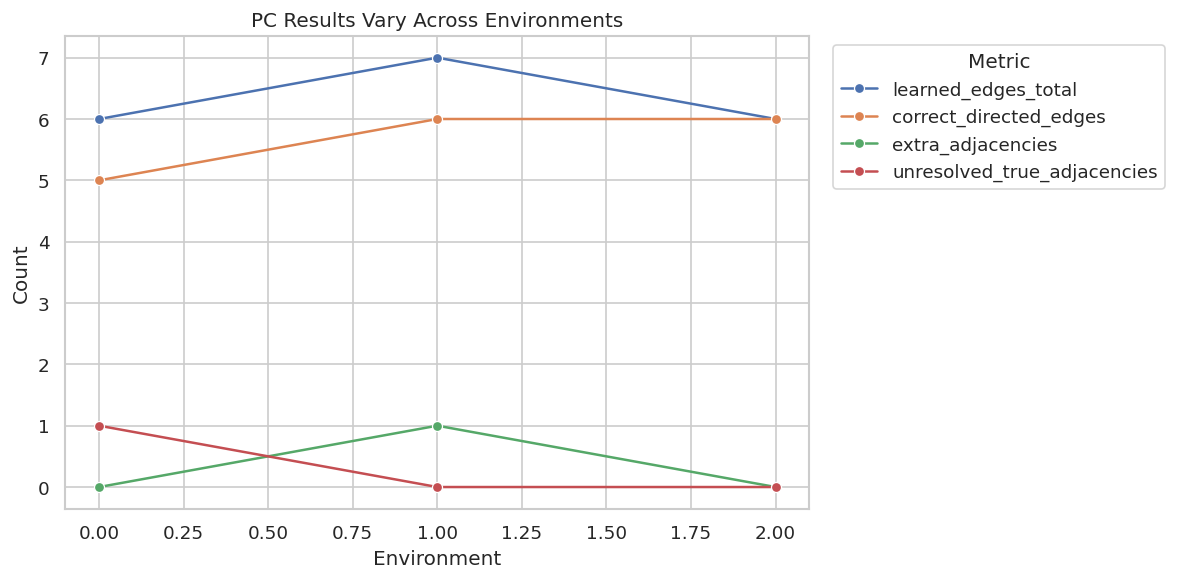

In [14]:
# Plot per-environment PC graph metrics.
metric_plot = per_environment_metrics_df.melt(
    id_vars=["run", "environment"],
    value_vars=["learned_edges_total", "correct_directed_edges", "extra_adjacencies", "unresolved_true_adjacencies"],
    var_name="metric",
    value_name="count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=metric_plot, x="environment", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("PC Results Vary Across Environments")
ax.set_xlabel("Environment")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_per_environment_pc_variation.png", dpi=160, bbox_inches="tight")
plt.show()

The plot shows why a pooled graph can be fragile. We now move to CD-NOD, which models the context index directly instead of running separate analyses after the fact.

## CD-NOD Without Background Knowledge

CD-NOD takes two inputs: the data matrix over observed variables and a separate `c_indx` matrix containing the environment or time index. causal-learn appends this context index internally, which is why the helper maps `X7` back to `environment`.

This first run uses no background knowledge, so it lets the algorithm orient edges using its own rules and the nonstationary signal.

In [15]:
# Run CD-NOD with the environment index and no background knowledge.
X = data_df[VARIABLES].to_numpy()
c_index = data_df[[ENV_COLUMN]].to_numpy()

cdnod_raw, cdnod_raw_messages = run_cdnod_quiet(
    X,
    c_index,
    label="cdnod_no_background_knowledge",
    alpha=0.05,
    background_knowledge=None,
)
cdnod_raw_edges = graph_to_edge_table(cdnod_raw.G, label="cdnod_no_background_knowledge", name_map=CDNOD_NAME_MAP)
cdnod_raw_metrics = summarize_against_truth(cdnod_raw_edges, true_edges, "cdnod_no_background_knowledge")
cdnod_raw_classified = classify_edges(cdnod_raw_edges, true_edges)

cdnod_raw_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_edges.csv", index=False)
cdnod_raw_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_metrics.csv", index=False)
cdnod_raw_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_edge_classification.csv", index=False)
cdnod_raw_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_messages.csv", index=False)

display(cdnod_raw_edges)
display(cdnod_raw_metrics)
display(cdnod_raw_classified)

,run,source,edge_type,target
0,cdnod_no_background_knowledge,match,-->,need
1,cdnod_no_background_knowledge,environment,-->,need
2,cdnod_no_background_knowledge,match,-->,intent
3,cdnod_no_background_knowledge,intent,-->,renewal
4,cdnod_no_background_knowledge,environment,-->,intent
5,cdnod_no_background_knowledge,match,---,engagement
6,cdnod_no_background_knowledge,engagement,-->,renewal
7,cdnod_no_background_knowledge,engagement,---,support


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,cdnod_no_background_knowledge,8,6,9,4,0.666667,0.444444,2,2,1,0


,source,edge_type,target,status
0,match,-->,need,reversed true edge
1,environment,-->,need,correct directed edge
2,match,-->,intent,reversed true edge
3,intent,-->,renewal,correct directed edge
4,environment,-->,intent,correct directed edge
5,match,---,engagement,true adjacency with uncertain or wrong endpoint
6,engagement,-->,renewal,correct directed edge
7,engagement,---,support,true adjacency with uncertain or wrong endpoint


The raw CD-NOD graph includes edges from the environment node, which ordinary PC cannot represent. Some ordinary directions are still reversed or unresolved, so this is not a perfect graph. The key gain is that nonstationary variables are now visible in the graph language.

## Draw The Raw CD-NOD Graph

This figure includes the environment node. Edges from `environment` should be read as nonstationarity or mechanism-shift signals rather than as recommendations for intervention.

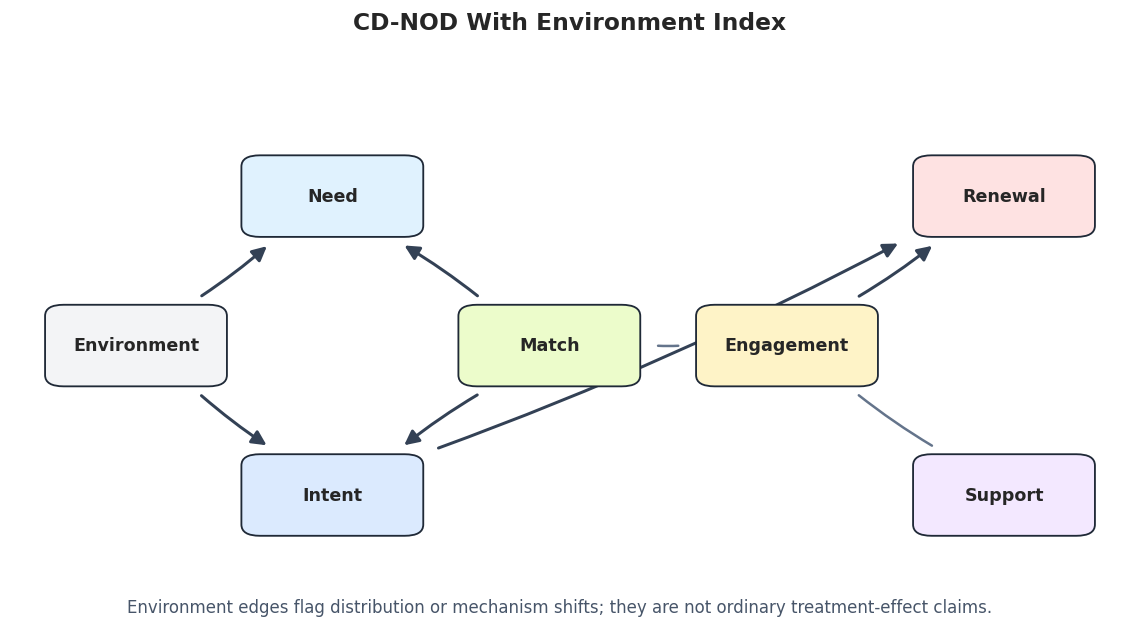

In [16]:
# Draw the raw CD-NOD graph.
cdnod_raw_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_graph.png"
draw_box_graph(
    cdnod_raw_edges,
    title="CD-NOD With Environment Index",
    path=cdnod_raw_graph_path,
    note="Environment edges flag distribution or mechanism shifts; they are not ordinary treatment-effect claims.",
    include_environment=True,
)

The graph makes the CD-NOD contribution visible: environment is part of the discovered structure. The next cell isolates those environment edges and compares them to the known shift targets.

## Environment Edge Recovery

The most distinctive CD-NOD output is the set of edges touching `environment`. In this synthetic dataset, the true environment-shift targets are `need`, `intent`, and `match`.

In [17]:
# Compare learned environment edges with the known environment-shift targets.
def environment_edge_summary(edge_df, label):
    env_edges = edge_df[(edge_df["source"] == ENV_COLUMN) | (edge_df["target"] == ENV_COLUMN)].copy()
    true_targets = set(shift_edges["target"])
    learned_targets = set()
    for row in env_edges.itertuples(index=False):
        if row.edge_type == "-->" and row.source == ENV_COLUMN:
            learned_targets.add(row.target)
        elif row.edge_type == "<--" and row.target == ENV_COLUMN:
            learned_targets.add(row.source)
    return env_edges, pd.DataFrame(
        [
            {
                "run": label,
                "true_environment_targets": sorted(true_targets),
                "learned_environment_targets": sorted(learned_targets),
                "correct_environment_targets": sorted(true_targets & learned_targets),
                "missing_environment_targets": sorted(true_targets - learned_targets),
                "extra_environment_targets": sorted(learned_targets - true_targets),
            }
        ]
    )

cdnod_raw_env_edges, cdnod_raw_env_summary = environment_edge_summary(cdnod_raw_edges, "cdnod_no_background_knowledge")
cdnod_raw_env_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_environment_edges.csv", index=False)
cdnod_raw_env_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_no_background_environment_summary.csv", index=False)

display(shift_edges)
display(cdnod_raw_env_edges)
display(cdnod_raw_env_summary)

,source,target,edge_type,mechanism
6,environment,need,directed,The root need distribution shifts by environment.
7,environment,intent,directed,The root intent distribution shifts by environ...
8,environment,match,directed,The intent-to-match mechanism changes by envir...


,run,source,edge_type,target
1,cdnod_no_background_knowledge,environment,-->,need
4,cdnod_no_background_knowledge,environment,-->,intent


,run,true_environment_targets,learned_environment_targets,correct_environment_targets,missing_environment_targets,extra_environment_targets
0,cdnod_no_background_knowledge,"[intent, match, need]","[intent, need]","[intent, need]",[match],[]


The raw CD-NOD run recovers some environment-shift targets and may miss others. That is a useful, realistic outcome: CD-NOD highlights nonstationarity, but the recovered environment edges still need sensitivity checks and domain review.

## CD-NOD With Simple Temporal Background Knowledge

The prior notebook showed that valid background knowledge can prevent impossible directions. Here we use a simple tier order:

- environment is a context/root index;
- `need` and `intent` come early;
- `match` comes after early context;
- `engagement` comes after match;
- `renewal` and `support` are downstream outcomes.

This does not force every forward edge to exist. It only blocks directions that violate the intended ordering.

In [18]:
# Build and audit tier-based background knowledge for CD-NOD's internal X-name convention.
cdnod_background_knowledge, cdnod_tiers = make_cdnod_background_knowledge()

knowledge_rows = []
for source, source_tier in cdnod_tiers.items():
    for target, target_tier in cdnod_tiers.items():
        if source == target:
            continue
        source_node = GraphNode(REVERSE_CDNOD_NAME_MAP[source])
        target_node = GraphNode(REVERSE_CDNOD_NAME_MAP[target])
        if cdnod_background_knowledge.is_forbidden(source_node, target_node):
            knowledge_rows.append(
                {
                    "forbidden_direction": f"{source} -> {target}",
                    "reason": "later-to-earlier tier" if source_tier > target_tier else "within downstream outcome tier",
                }
            )

cdnod_knowledge_table = pd.DataFrame(knowledge_rows)
cdnod_tier_table = pd.DataFrame([{"variable": variable, "tier": tier} for variable, tier in cdnod_tiers.items()])
cdnod_tier_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_background_tiers.csv", index=False)
cdnod_knowledge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_background_forbidden_edges.csv", index=False)

display(cdnod_tier_table.sort_values("tier"))
display(cdnod_knowledge_table)

,variable,tier
0,environment,0
1,need,1
2,intent,1
3,match,2
4,engagement,3
5,renewal,4
6,support,4


,forbidden_direction,reason
0,need -> environment,later-to-earlier tier
1,intent -> environment,later-to-earlier tier
2,match -> environment,later-to-earlier tier
3,match -> need,later-to-earlier tier
4,match -> intent,later-to-earlier tier
5,engagement -> environment,later-to-earlier tier
6,engagement -> need,later-to-earlier tier
7,engagement -> intent,later-to-earlier tier
8,engagement -> match,later-to-earlier tier
9,renewal -> environment,later-to-earlier tier


The background-knowledge table is the audit trail for the constraints. The constraints are based on timing and role assumptions, not on a desire to force the graph to match the answer key.

## Structured CD-NOD Run

Now we rerun CD-NOD with the same data, same environment index, and same alpha, but with the tier-based background knowledge. The purpose is to see how much the graph becomes more interpretable when implausible directions are removed.

In [19]:
# Run CD-NOD with tier-based background knowledge.
cdnod_structured, cdnod_structured_messages = run_cdnod_quiet(
    X,
    c_index,
    label="cdnod_with_background_knowledge",
    alpha=0.05,
    background_knowledge=cdnod_background_knowledge,
)
cdnod_structured_edges = graph_to_edge_table(
    cdnod_structured.G,
    label="cdnod_with_background_knowledge",
    name_map=CDNOD_NAME_MAP,
)
cdnod_structured_metrics = summarize_against_truth(cdnod_structured_edges, true_edges, "cdnod_with_background_knowledge")
cdnod_structured_classified = classify_edges(cdnod_structured_edges, true_edges)

cdnod_structured_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_with_background_edges.csv", index=False)
cdnod_structured_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_with_background_metrics.csv", index=False)
cdnod_structured_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_with_background_edge_classification.csv", index=False)
cdnod_structured_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_with_background_messages.csv", index=False)

display(cdnod_structured_edges)
display(cdnod_structured_metrics)
display(cdnod_structured_classified)

,run,source,edge_type,target
0,cdnod_with_background_knowledge,need,-->,match
1,cdnod_with_background_knowledge,environment,-->,need
2,cdnod_with_background_knowledge,intent,-->,match
3,cdnod_with_background_knowledge,intent,-->,renewal
4,cdnod_with_background_knowledge,environment,-->,intent
5,cdnod_with_background_knowledge,match,-->,engagement
6,cdnod_with_background_knowledge,engagement,-->,renewal
7,cdnod_with_background_knowledge,engagement,-->,support


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,cdnod_with_background_knowledge,8,8,9,8,1.0,0.888889,0,0,1,0


,source,edge_type,target,status
0,need,-->,match,correct directed edge
1,environment,-->,need,correct directed edge
2,intent,-->,match,correct directed edge
3,intent,-->,renewal,correct directed edge
4,environment,-->,intent,correct directed edge
5,match,-->,engagement,correct directed edge
6,engagement,-->,renewal,correct directed edge
7,engagement,-->,support,correct directed edge


The structured CD-NOD run is easier to read. The ordinary causal directions align better with the teaching order, and the environment node still marks shifting root variables. The graph can still miss a true shift target, which is exactly why we keep the evaluation table visible.

## Draw The Structured CD-NOD Graph

This graph is the cleanest candidate structure in the notebook. It combines CD-NOD's environment-index idea with simple background knowledge about timing.

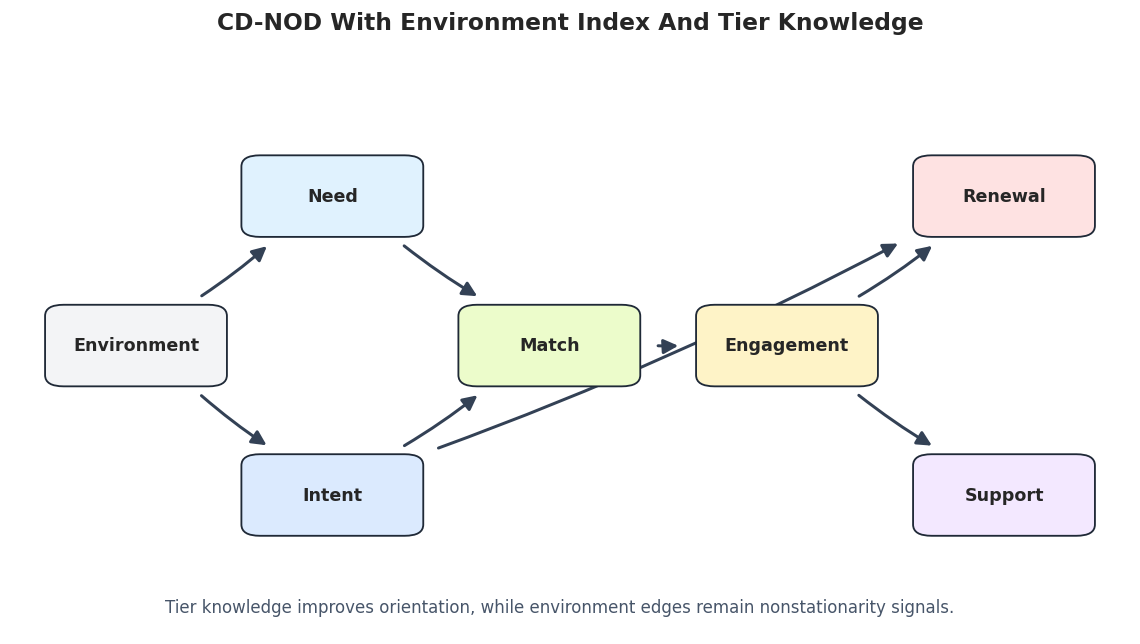

In [20]:
# Draw the structured CD-NOD graph.
cdnod_structured_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_with_background_graph.png"
draw_box_graph(
    cdnod_structured_edges,
    title="CD-NOD With Environment Index And Tier Knowledge",
    path=cdnod_structured_graph_path,
    note="Tier knowledge improves orientation, while environment edges remain nonstationarity signals.",
    include_environment=True,
)

The structured graph is the most reportable candidate, but the correct wording remains cautious: it is a discovery result under assumptions, not a confirmed causal DAG.

## Compare Pooled PC, Raw CD-NOD, And Structured CD-NOD

The next table puts the main runs side by side. Pooled PC is evaluated only against ordinary observed-variable edges because it does not include the environment node. CD-NOD runs are evaluated against the augmented truth table that includes environment-shift edges.

,run,graph_scope,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,pooled_pc_ignoring_environment,observed variables only,7,2,6,2,1.000000,0.333333,0,4,0,1
1,cdnod_no_background_knowledge,observed variables plus environment,8,6,9,4,0.666667,0.444444,2,2,1,0
2,cdnod_with_background_knowledge,observed variables plus environment,8,8,9,8,1.000000,0.888889,0,0,1,0


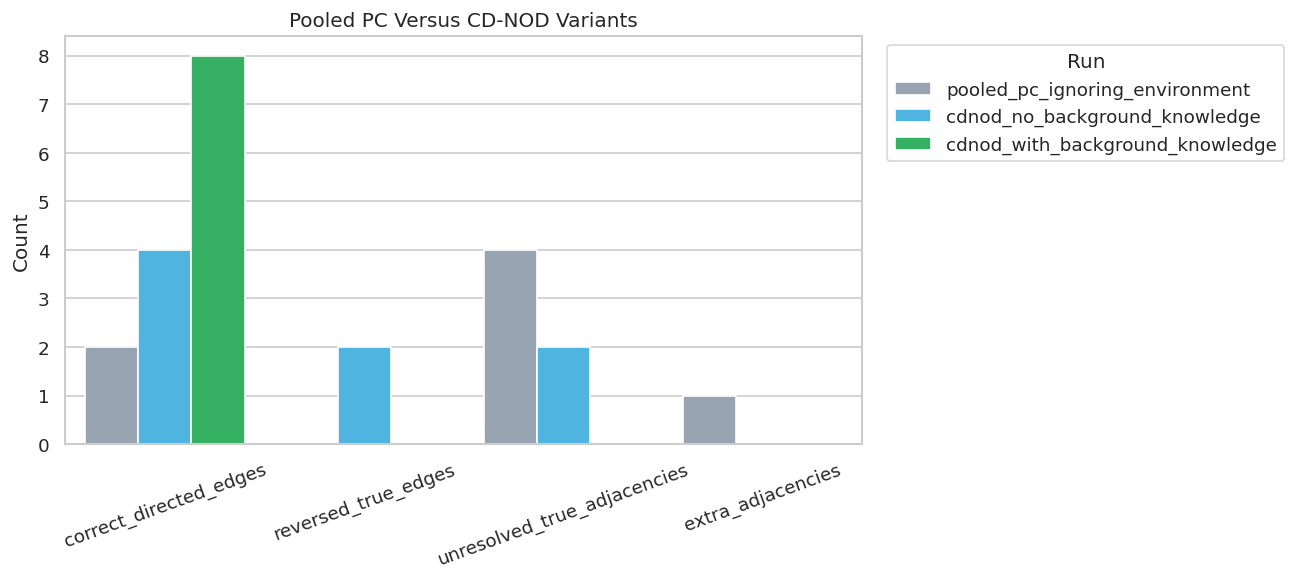

In [21]:
# Combine the main metric summaries.
main_comparison = pd.concat(
    [pooled_pc_metrics, cdnod_raw_metrics, cdnod_structured_metrics],
    ignore_index=True,
)
main_comparison["graph_scope"] = ["observed variables only", "observed variables plus environment", "observed variables plus environment"]
main_comparison = main_comparison[["run", "graph_scope"] + [col for col in main_comparison.columns if col not in {"run", "graph_scope"}]]
main_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_main_method_comparison_metrics.csv", index=False)

display(main_comparison)

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = main_comparison.melt(
    id_vars=["run", "graph_scope"],
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=plot_df, x="metric", y="count", hue="run", ax=ax, palette=["#94a3b8", "#38bdf8", "#22c55e"])
ax.set_title("Pooled PC Versus CD-NOD Variants")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_main_method_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The comparison shows the tradeoff clearly. CD-NOD is valuable because it can represent context-linked nonstationarity; background knowledge helps orient the graph; neither step removes the need for sensitivity analysis.

## Alpha Sensitivity For Structured CD-NOD

CD-NOD still depends on conditional independence tests, so the alpha threshold matters. This cell reruns the structured CD-NOD workflow across several alpha values and records graph-recovery metrics.

In [22]:
# Run structured CD-NOD across alpha values.
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.10, 0.20]
alpha_metric_tables = []
alpha_edge_tables = []
alpha_message_tables = []

for alpha in alpha_values:
    label = f"structured_cdnod_alpha_{alpha:g}"
    result, messages = run_cdnod_quiet(
        X,
        c_index,
        label=label,
        alpha=alpha,
        background_knowledge=cdnod_background_knowledge,
    )
    edge_table = graph_to_edge_table(result.G, label=label, name_map=CDNOD_NAME_MAP).assign(alpha=alpha)
    metrics = summarize_against_truth(edge_table.drop(columns=["alpha"]), true_edges, label).assign(alpha=alpha)
    alpha_edge_tables.append(edge_table)
    alpha_metric_tables.append(metrics)
    alpha_message_tables.append(messages.assign(alpha=alpha))

alpha_edges = pd.concat(alpha_edge_tables, ignore_index=True)
alpha_metrics = pd.concat(alpha_metric_tables, ignore_index=True)
alpha_messages = pd.concat(alpha_message_tables, ignore_index=True)

alpha_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_structured_cdnod_alpha_edges.csv", index=False)
alpha_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_structured_cdnod_alpha_metrics.csv", index=False)
alpha_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_structured_cdnod_alpha_messages.csv", index=False)

display(alpha_metrics)
display(alpha_edges.head(20))

,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,alpha
0,structured_cdnod_alpha_0.001,8,8,9,8,1.000000,0.888889,0,0,1,0,0.001
1,structured_cdnod_alpha_0.005,8,8,9,8,1.000000,0.888889,0,0,1,0,0.005
2,structured_cdnod_alpha_0.01,8,8,9,8,1.000000,0.888889,0,0,1,0,0.010
3,structured_cdnod_alpha_0.05,8,8,9,8,1.000000,0.888889,0,0,1,0,0.050
4,structured_cdnod_alpha_0.1,9,9,9,8,0.888889,0.888889,0,0,1,1,0.100
5,structured_cdnod_alpha_0.2,9,9,9,8,0.888889,0.888889,0,0,1,1,0.200


,run,source,edge_type,target,alpha
0,structured_cdnod_alpha_0.001,need,-->,match,0.001
1,structured_cdnod_alpha_0.001,environment,-->,need,0.001
2,structured_cdnod_alpha_0.001,intent,-->,match,0.001
3,structured_cdnod_alpha_0.001,intent,-->,renewal,0.001
4,structured_cdnod_alpha_0.001,environment,-->,intent,0.001
5,structured_cdnod_alpha_0.001,match,-->,engagement,0.001
6,structured_cdnod_alpha_0.001,engagement,-->,renewal,0.001
7,structured_cdnod_alpha_0.001,engagement,-->,support,0.001
8,structured_cdnod_alpha_0.005,need,-->,match,0.005
9,structured_cdnod_alpha_0.005,environment,-->,need,0.005


The alpha table shows which results are stable and which only appear under more permissive thresholds. Stable environment and ordinary edges deserve more attention than tuning-specific ones.

## Plot Structured CD-NOD Alpha Sensitivity

The plot tracks key graph counts across alpha values. It makes it easier to see whether increasing alpha mainly adds useful true edges, extra edges, or both.

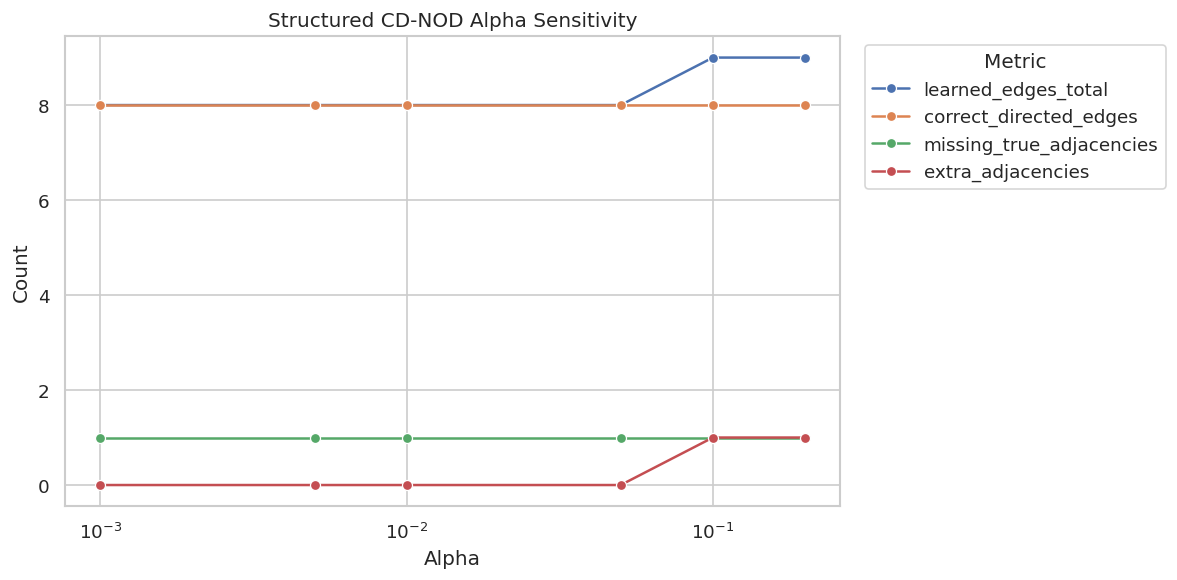

In [23]:
# Plot alpha sensitivity for structured CD-NOD.
fig, ax = plt.subplots(figsize=(10, 5))
alpha_plot = alpha_metrics.melt(
    id_vars=["run", "alpha"],
    value_vars=["learned_edges_total", "correct_directed_edges", "missing_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.lineplot(data=alpha_plot, x="alpha", y="count", hue="metric", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_title("Structured CD-NOD Alpha Sensitivity")
ax.set_xlabel("Alpha")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_structured_cdnod_alpha_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The sensitivity plot is a useful reporting companion to the chosen graph. It tells the reader whether the graph is stable over a reasonable tuning range or dependent on one particular alpha value.

## Environment Target Sensitivity

The most CD-NOD-specific part of the result is the learned set of environment targets. This cell extracts those targets at each alpha value and compares them with the true shift targets.

In [24]:
# Summarize learned environment targets across alpha values.
environment_sensitivity_rows = []
true_environment_targets = set(shift_edges["target"])
for alpha, group in alpha_edges.groupby("alpha"):
    env_edges, env_summary = environment_edge_summary(group.drop(columns=["alpha"]), f"structured_cdnod_alpha_{alpha:g}")
    row = env_summary.iloc[0].to_dict()
    row["alpha"] = alpha
    row["environment_edge_count"] = len(env_edges)
    environment_sensitivity_rows.append(row)

environment_sensitivity = pd.DataFrame(environment_sensitivity_rows).sort_values("alpha")
environment_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_environment_target_sensitivity.csv", index=False)
display(environment_sensitivity)

,run,true_environment_targets,learned_environment_targets,correct_environment_targets,missing_environment_targets,extra_environment_targets,alpha,environment_edge_count
0,structured_cdnod_alpha_0.001,"[intent, match, need]","[intent, need]","[intent, need]",[match],[],0.001,2
1,structured_cdnod_alpha_0.005,"[intent, match, need]","[intent, need]","[intent, need]",[match],[],0.005,2
2,structured_cdnod_alpha_0.01,"[intent, match, need]","[intent, need]","[intent, need]",[match],[],0.010,2
3,structured_cdnod_alpha_0.05,"[intent, match, need]","[intent, need]","[intent, need]",[match],[],0.050,2
4,structured_cdnod_alpha_0.1,"[intent, match, need]","[intent, need, renewal]","[intent, need]",[match],[renewal],0.100,3
5,structured_cdnod_alpha_0.2,"[intent, match, need]","[intent, need, renewal]","[intent, need]",[match],[renewal],0.200,3


This table keeps environment-edge claims appropriately narrow. A learned environment edge means that a variable appears connected to nonstationarity under the method and tuning choice, not that the environment is a directly manipulable cause.

## CD-NOD Reporting Checklist

The final checklist converts the notebook into reusable reporting guidance. Nonstationary discovery reports need to document the environment index as carefully as the graph itself.

In [25]:
# Save a practical checklist for nonstationary causal discovery reports.
reporting_checklist = pd.DataFrame(
    [
        {
            "topic": "environment definition",
            "question_to_answer": "What does the environment or time index represent, and why should it capture distribution shift?",
            "reporting_note": "Do not treat environment as a normal treatment unless that reading is justified.",
        },
        {
            "topic": "shift diagnostics",
            "question_to_answer": "Which variables or relationships visibly change across environments before discovery?",
            "reporting_note": "Show simple summaries such as means, slopes, or distribution plots.",
        },
        {
            "topic": "pooled baseline",
            "question_to_answer": "How does ordinary pooled PC behave when environment is ignored?",
            "reporting_note": "Use this as a diagnostic for stationary-model fragility.",
        },
        {
            "topic": "environment edges",
            "question_to_answer": "Which variables are connected to the environment node, and are those edges stable?",
            "reporting_note": "Interpret them as nonstationarity or mechanism-shift signals.",
        },
        {
            "topic": "background knowledge",
            "question_to_answer": "What ordering constraints were used, and are they justified by timing or domain design?",
            "reporting_note": "Invalid constraints can make the graph look cleaner than the evidence supports.",
        },
        {
            "topic": "sensitivity",
            "question_to_answer": "How do the graph and environment targets change across alpha values?",
            "reporting_note": "Stable findings deserve more weight than tuning-specific edges.",
        },
    ]
)
reporting_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cdnod_reporting_checklist.csv", index=False)
display(reporting_checklist)

,topic,question_to_answer,reporting_note
0,environment definition,What does the environment or time index repres...,Do not treat environment as a normal treatment...
1,shift diagnostics,Which variables or relationships visibly chang...,"Show simple summaries such as means, slopes, o..."
2,pooled baseline,How does ordinary pooled PC behave when enviro...,Use this as a diagnostic for stationary-model ...
3,environment edges,Which variables are connected to the environme...,Interpret them as nonstationarity or mechanism...
4,background knowledge,"What ordering constraints were used, and are t...",Invalid constraints can make the graph look cl...
5,sensitivity,How do the graph and environment targets chang...,Stable findings deserve more weight than tunin...


The checklist is the practical endpoint of the notebook. CD-NOD gives us a way to use domain/time variation, but careful reporting is what keeps the result from being overinterpreted.

## Artifact Manifest

The final cell lists the key files generated by this notebook. This makes the saved tables and figures easy to find later.

In [26]:
# Inventory artifacts generated by this notebook.
artifact_rows = []
for folder, artifact_type in [(TABLE_DIR, "table"), (FIGURE_DIR, "figure")]:
    for artifact_path in sorted(folder.glob(f"{NOTEBOOK_PREFIX}_*")):
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "file_name": artifact_path.name,
                "relative_path": str(artifact_path.relative_to(NOTEBOOK_DIR)),
                "size_kb": round(artifact_path.stat().st_size / 1024, 1),
            }
        )

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,file_name,relative_path,size_kb
0,table,07_artifact_manifest.csv,outputs/tables/07_artifact_manifest.csv,3.9
1,table,07_cdnod_background_forbidden_edges.csv,outputs/tables/07_cdnod_background_forbidden_e...,0.9
2,table,07_cdnod_background_tiers.csv,outputs/tables/07_cdnod_background_tiers.csv,0.1
3,table,07_cdnod_no_background_edge_classification.csv,outputs/tables/07_cdnod_no_background_edge_cla...,0.4
4,table,07_cdnod_no_background_edges.csv,outputs/tables/07_cdnod_no_background_edges.csv,0.4
5,table,07_cdnod_no_background_environment_edges.csv,outputs/tables/07_cdnod_no_background_environm...,0.1
6,table,07_cdnod_no_background_environment_summary.csv,outputs/tables/07_cdnod_no_background_environm...,0.2
7,table,07_cdnod_no_background_messages.csv,outputs/tables/07_cdnod_no_background_messages...,3.0
8,table,07_cdnod_no_background_metrics.csv,outputs/tables/07_cdnod_no_background_metrics.csv,0.3
9,table,07_cdnod_reporting_checklist.csv,outputs/tables/07_cdnod_reporting_checklist.csv,1.0


The notebook now has a complete CD-NOD workflow: nonstationary data audit, pooled and per-environment PC diagnostics, CD-NOD with and without background knowledge, alpha sensitivity, environment-target reporting, and a saved artifact trail. The next tutorial can move from constraint-based nonstationary discovery to score-based discovery with GES.